# Real World Classification

## Load data

Import the necessary libraries

In [49]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [51]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [52]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------

    cols_with_missing = [col for col in feature_cols if df[col].isnull().sum() > 0]

    print("--- 3(a) Before Imputation ---")
    for col in cols_with_missing:
        print(f"{col} - Median : {df[col].median():.4f}, Std : {df[col].std():.4f}")
    
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])

    print("\n--- 3(b) After Imputation ---")
    for col in cols_with_missing:
        print(f"{col} - Median: {df[col].median():.4f}, Std: {df[col].std():.4f}")
    
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

--- 3(a) Before Imputation ---
SepalLengthCm - Median : 6.3000, Std : 1.0371
SepalWidthCm - Median : 2.9000, Std : 0.3896
PetalLengthCm - Median : 5.0856, Std : 1.5828
PetalWidthCm - Median : 1.6000, Std : 0.7067
BranchLength - Median : 16.3000, Std : 1.0352

--- 3(b) After Imputation ---
SepalLengthCm - Median: 6.3000, Std: 1.0093
SepalWidthCm - Median: 2.9000, Std: 0.3724
PetalLengthCm - Median: 5.0357, Std: 1.5150
PetalWidthCm - Median: 1.7000, Std: 0.6946
BranchLength - Median: 16.3000, Std: 1.0110


In [53]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

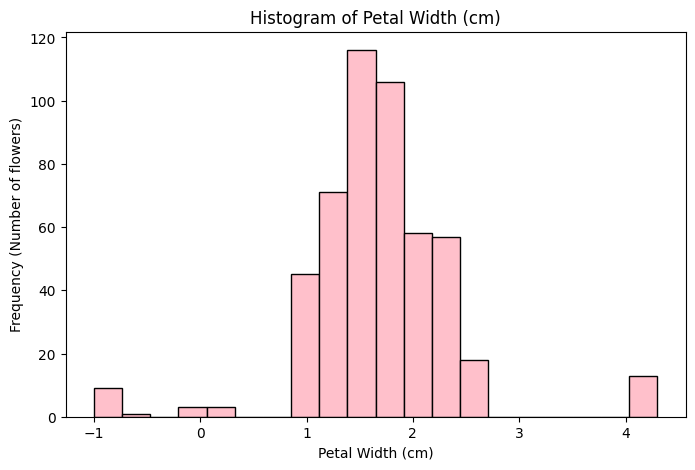

--- Pearson Correlation with PetalWidthCm ---
SepalLengthCm : 0.0391
SepalWidthCm : -0.0653
PetalLengthCm : 0.3440
BranchLength : 0.0306
AvgDust : 0.0966
SepalLengthMajorAxis : 0.0349
SepalLengthMinorAxis : 0.0331
SepalLengthElongation : 0.0259
SepalLengthCompactness : 0.0217
SepalLengthSpread : 0.0392
SepalLengthCurvature : 0.0422
SepalWidthMajorAxis : -0.0964
SepalWidthMinorAxis : -0.0744
SepalWidthElongation : -0.0692
SepalWidthCompactness : -0.0885
SepalWidthSpread : -0.0615
SepalWidthCurvature : -0.0813
PetalLengthMajorAxis : 0.3276
PetalLengthMinorAxis : 0.3228
PetalLengthElongation : 0.3232
PetalLengthCompactness : 0.3264
PetalLengthSpread : 0.3265
PetalLengthCurvature : 0.3273
PetalWidthMajorAxis : 0.9911
PetalWidthMinorAxis : 0.9910
PetalWidthElongation : 0.9916
PetalWidthCompactness : 0.9917
PetalWidthSpread : 0.9911
PetalWidthCurvature : 0.9913
IrisPigmentDensity : -0.0234
IrisPigmentUniformity : -0.0074
IrisPigmentContrast : -0.0154
IrisPigmentGranularity : -0.0041
IrisVena

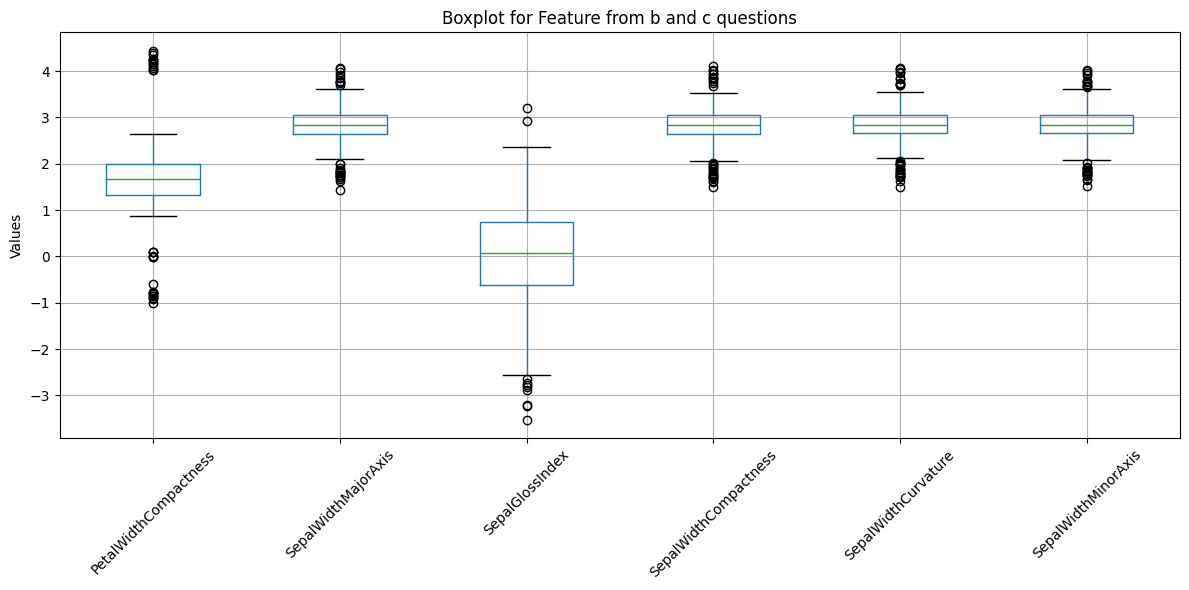

In [54]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration
plt.figure(figsize=(8, 5))
plt.hist(df['PetalWidthCm'], bins=20, color='pink', edgecolor='black')

plt.title('Histogram of Petal Width (cm)')
plt.xlabel('Petal Width (cm)')
plt.ylabel('Frequency (Number of flowers)')

plt.show()

features_to_check = [col for col in df.columns if col not in ['PetalWidthCm', 'Species', 'Id']]

X = df[features_to_check]
y = df['PetalWidthCm']

correlations = r_regression(X, y)

print("--- Pearson Correlation with PetalWidthCm ---")
for i, col in enumerate(features_to_check):
    print(f"{col} : {correlations[i]:.4f}")

max_index = np.argmax(correlations)
best_feature = features_to_check[max_index]

print(f"\n --> the feature with the largest positive correlation is : {best_feature} (Score : {correlations[max_index]:.4f})")

sorted_indices = np.argsort(correlations)

print("\n \n --- Top 5 Strongest Negative Correlations with PetalWidthCm ---")
for i in range(5):
    idx = sorted_indices[i]
    feature = features_to_check[idx]
    score = correlations[idx]
    print(f"{i+1}. {feature} : {score:.4f}")

features_to_plot = ['PetalWidthCompactness', 'SepalWidthMajorAxis', 'SepalGlossIndex', 'SepalWidthCompactness', 'SepalWidthCurvature', 'SepalWidthMinorAxis']

plt.figure(figsize=(12, 6))

df.boxplot(column=features_to_plot)

plt.title('Boxplot for Feature from b and c questions')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Model Training

### Prepare the data

In [55]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### K-fold Cross-Validation
 
 Question 1 : a.

In [56]:
from sklearn.model_selection import KFold, cross_val_score
from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid

# Define the hyperparameters to evaluate (16 combinations in total)
learning_rates = [0.005, 0.01, 0.1, 0.5]
reg_lambdas = [1.0, 2.0, 4.0, 8.0]

# Initialize a 4x4 matrix to store average accuracy scores
results_matrix = np.zeros((len(learning_rates), len(reg_lambdas)))

# Configure 5-fold cross-validation on training data with fixed random state
kf = KFold(n_splits=5, shuffle=True, random_state=40)

# Evaluate each combination of learning rate and regularization lambda
for i, lr in enumerate(learning_rates):
    for j, reg_lambda in enumerate(reg_lambdas):
        
        # Initialize the model with L2 regularization
        model = LinearModel(
            dim=X_train.shape[1], 
            is_reg=False, 
            loss_fn=logloss, 
            act_fn=sigmoid, 
            grad_fn=logloss_sigmoid_grad,
            lr=lr, 
            reg_type='l2', 
            reg_lambda=reg_lambda,
            plot_curve=False
        )
        
        # Compute cross-validation scores using 5 folds on training data
        scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
        
        # Calculate and store the average accuracy
        avg_accuracy = np.mean(scores)
        results_matrix[i, j] = avg_accuracy

# Create a Pandas DataFrame to display the 4x4 results table
df_results = pd.DataFrame(
    results_matrix, 
    index=[f"LR={lr}" for lr in learning_rates], 
    columns=[f"Lambda={l}" for l in reg_lambdas]
)

print("--- Question 1(a): 5-Fold Cross-Validation Average Accuracy (4x4 Table) ---")
print(df_results)

50. Training loss: 5.342222710887697, Val loss:6.1610051619687605
50. Training loss: 5.38585819591835, Val loss:5.336483975192538
50. Training loss: 5.1911013480741195, Val loss:6.373231060990504
50. Training loss: 5.499483012313176, Val loss:5.962055508671761
50. Training loss: 5.44699602582878, Val loss:5.13618636761724
50. Training loss: 5.345292180193646, Val loss:6.167643284831131
50. Training loss: 5.39668912423349, Val loss:5.345292180193648
50. Training loss: 5.1911013480741195, Val loss:6.373231060990504
50. Training loss: 5.499483012313176, Val loss:5.962055508671761
50. Training loss: 5.448086068273333, Val loss:5.139704404034276
50. Training loss: 5.345292180193646, Val loss:6.167643284831131
50. Training loss: 5.396428301602232, Val loss:5.345292180193648
50. Training loss: 5.1911013480741195, Val loss:6.373231060990504
50. Training loss: 5.452858681956442, Val loss:5.957943025795314
50. Training loss: 5.448086068273333, Val loss:5.139704404034276
50. Training loss: 5.3452

Question 1 : b.

========== TOP CONFIGURATION 1 ==========
Hyperparameters: Learning Rate = 0.1, Regularization Lambda = 4.0
50. Training loss: 0.7139059737509182, Val loss:0.7437254394964692
100. Training loss: 0.6660623213977204, Val loss:0.6981354701883886
150. Training loss: 0.6339394409809048, Val loss:0.6681465204774968
200. Training loss: 0.6119353189631901, Val loss:0.6480752937715514
250. Training loss: 0.596531326336121, Val loss:0.6343572580716574
300. Training loss: 0.5855226361511795, Val loss:0.6247794917162988
350. Training loss: 0.5775093336429606, Val loss:0.6179582361217478
400. Training loss: 0.57158405200694, Val loss:0.6130136835705138
450. Training loss: 0.5671447208777791, Val loss:0.6093745136424977
500. Training loss: 0.5637822939801901, Val loss:0.6066612739267297
550. Training loss: 0.5612125943009799, Val loss:0.6046162879347621
600. Training loss: 0.5592341596643664, Val loss:0.6030608851969251
650. Training loss: 0.5577015960104148, Val loss:0.6018688007705492
700. Trainin

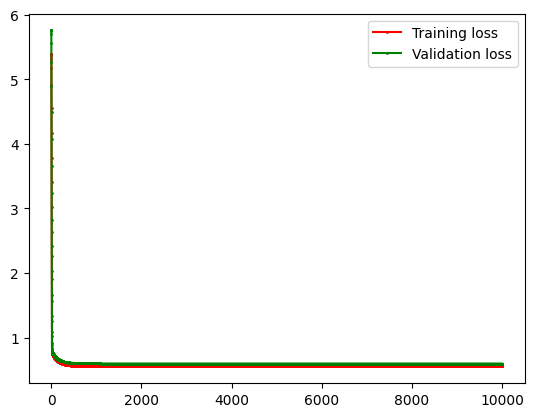

Model Evaluation
Accuracy  : 0.7400
Precision : 0.7176
Recall    : 0.8026
F1-score  : 0.7578


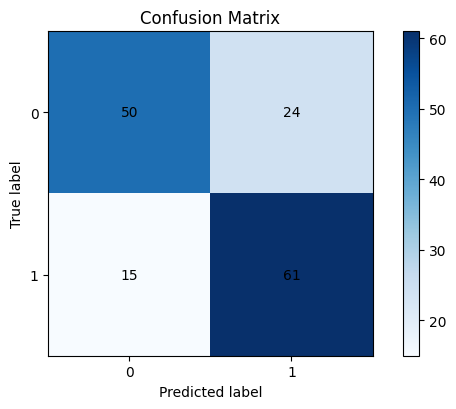


========== TOP CONFIGURATION 2 ==========
Hyperparameters: Learning Rate = 0.1, Regularization Lambda = 8.0
50. Training loss: 0.636207548877147, Val loss:0.6500312240397192
100. Training loss: 0.6157298802751571, Val loss:0.6367129191184119
150. Training loss: 0.6049989058235182, Val loss:0.6301204496322994
200. Training loss: 0.599047754396894, Val loss:0.6266478058870693
250. Training loss: 0.5956132161157174, Val loss:0.6247373797188666
300. Training loss: 0.5935779156634258, Val loss:0.6236585232274786
350. Training loss: 0.5923506912259926, Val loss:0.6230415886128192
400. Training loss: 0.5916022605426962, Val loss:0.6226882196359534
450. Training loss: 0.591142461329762, Val loss:0.6224874607343237
500. Training loss: 0.5908587076211331, Val loss:0.6223755428522769
550. Training loss: 0.590683188952846, Val loss:0.6223152228669289
600. Training loss: 0.5905745705156988, Val loss:0.6222845785403874
650. Training loss: 0.590507441377804, Val loss:0.6222706882151963
700. Training

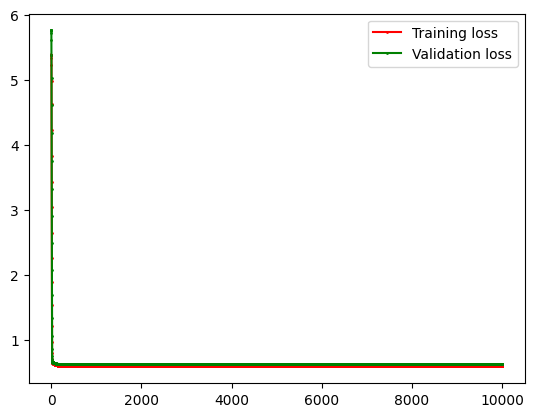

Model Evaluation
Accuracy  : 0.7200
Precision : 0.6700
Recall    : 0.8816
F1-score  : 0.7614


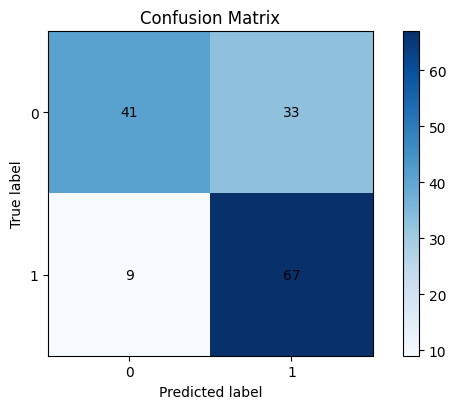

{'Accuracy': 0.72,
 'Precision': 0.67,
 'Recall': 0.881578947368421,
 'F1-score': 0.7613636363636364}

In [57]:
from model.metrics import evaluate_binary_classifier

print("========== TOP CONFIGURATION 1 ==========")
print("Hyperparameters: Learning Rate = 0.1, Regularization Lambda = 4.0")

# Initialize and train the first model
model_1 = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=logloss, act_fn=sigmoid, grad_fn=logloss_sigmoid_grad)
model_1.fit(X_train, y_train, lr=0.1, n_iteration=10000, val_ratio=0.2, reg_type='l2', reg_lambda=4.0)

# Predict and evaluate on unseen test data
y_pred_1 = model_1.predict(X_test)
evaluate_binary_classifier(y_test, y_pred_1)


print("\n========== TOP CONFIGURATION 2 ==========")
print("Hyperparameters: Learning Rate = 0.1, Regularization Lambda = 8.0")

# Initialize and train the second model
model_2 = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=logloss, act_fn=sigmoid, grad_fn=logloss_sigmoid_grad)
model_2.fit(X_train, y_train, lr=0.1, n_iteration=10000, val_ratio=0.2, reg_type='l2', reg_lambda=8.0)

# Predict and evaluate on unseen test data
y_pred_2 = model_2.predict(X_test)
evaluate_binary_classifier(y_test, y_pred_2)

### SVM

Question 2 : a

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# 1. Load the new dataset
df_mobile = pd.read_csv('data/mobile_price.csv')

# Separate features (X) and target label (y)
X_mobile = df_mobile.drop('price_range', axis=1)
y_mobile = df_mobile['price_range']

# 2. Split the data into Train (60%), Validation (20%), and Test (20%)
# First, split into Train (60%) and Temporary (40%)
X_train_temp, X_temp, y_train_temp, y_temp = train_test_split(
    X_mobile, y_mobile, test_size=0.40, random_state=42
)

# Then, split the Temporary data equally into Validation (50% of 40% = 20%) and Test (50% of 40% = 20%)
X_val, X_test_svm, y_val, y_test_svm = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

# 3. Train the initial SVM classifier with C = 1.0
svm_model = SVC(C=1.0, random_state=42)
svm_model.fit(X_train_temp, y_train_temp)

# 4. Evaluate the model on Train, Validation, and Test sets
# Predictions
y_pred_train = svm_model.predict(X_train_temp)
y_pred_val = svm_model.predict(X_val)
y_pred_test = svm_model.predict(X_test_svm)

# Accuracy and F1-score calculations (using 'macro' average for multiclass)
print("--- SVM Performance with C = 1.0 ---")
print(f"Training Data   - Accuracy: {accuracy_score(y_train_temp, y_pred_train):.4f}, F1-score: {f1_score(y_train_temp, y_pred_train, average='macro'):.4f}")
print(f"Validation Data - Accuracy: {accuracy_score(y_val, y_pred_val):.4f}, F1-score: {f1_score(y_val, y_pred_val, average='macro'):.4f}")
print(f"Testing Data    - Accuracy: {accuracy_score(y_test_svm, y_pred_test):.4f}, F1-score: {f1_score(y_test_svm, y_pred_test, average='macro'):.4f}")

--- SVM Performance with C = 1.0 ---
Training Data   - Accuracy: 0.9450, F1-score: 0.9446
Validation Data - Accuracy: 0.9450, F1-score: 0.9453
Testing Data    - Accuracy: 0.9575, F1-score: 0.9569


Question 2 : b

SVM evaluation with different C values :

C=0.001    | Train Acc: 0.2550 | Val Acc: 0.2450 | Test Acc: 0.2400
C=0.01     | Train Acc: 0.4908 | Val Acc: 0.4875 | Test Acc: 0.4425
C=0.1      | Train Acc: 0.9050 | Val Acc: 0.9025 | Test Acc: 0.9000
C=1.0      | Train Acc: 0.9450 | Val Acc: 0.9450 | Test Acc: 0.9575
C=10.0     | Train Acc: 0.9658 | Val Acc: 0.9575 | Test Acc: 0.9650
C=100.0    | Train Acc: 0.9792 | Val Acc: 0.9725 | Test Acc: 0.9775
C=1000.0   | Train Acc: 0.9900 | Val Acc: 0.9700 | Test Acc: 0.9775
C=10000.0  | Train Acc: 0.9975 | Val Acc: 0.9700 | Test Acc: 0.9650


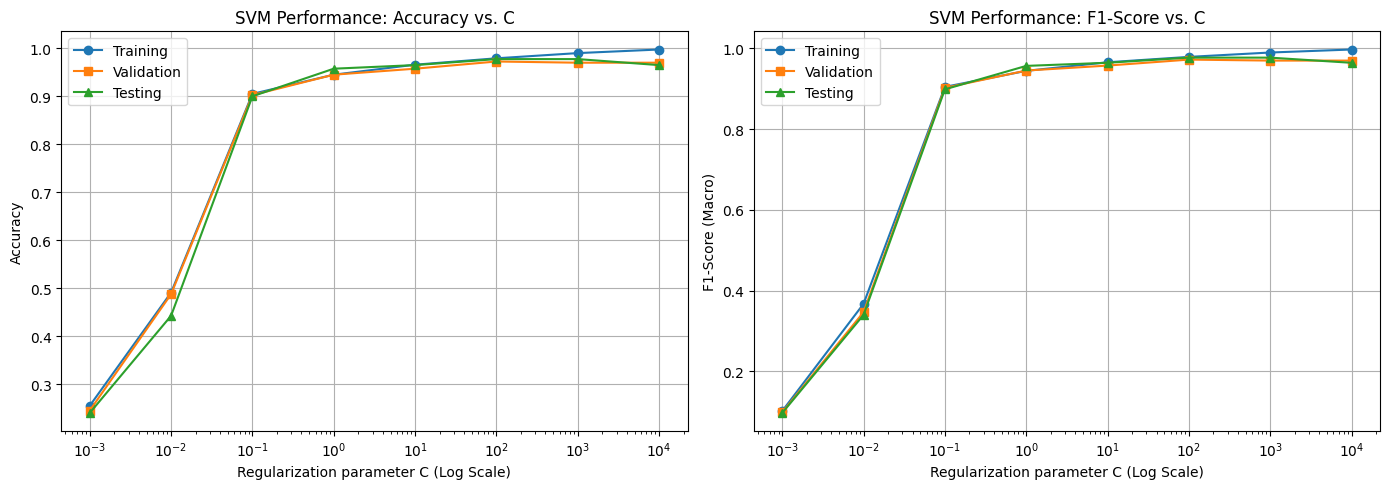

In [59]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# 1. Define the list of C values to test
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]

# Lists to store the scores for visualization
train_acc, val_acc, test_acc = [], [], []
train_f1, val_f1, test_f1 = [], [], []

print("SVM evaluation with different C values :\n")

# 2. Loop over each C value
for c in C_values:
    # Initialize and train the SVM model
    svm_model = SVC(C=c, random_state=42)
    svm_model.fit(X_train_temp, y_train_temp)
    
    # Generate predictions
    pred_train = svm_model.predict(X_train_temp)
    pred_val = svm_model.predict(X_val)
    pred_test = svm_model.predict(X_test_svm)
    
    # Calculate and store Accuracy
    train_acc.append(accuracy_score(y_train_temp, pred_train))
    val_acc.append(accuracy_score(y_val, pred_val))
    test_acc.append(accuracy_score(y_test_svm, pred_test))
    
    # Calculate and store F1-score (Macro)
    train_f1.append(f1_score(y_train_temp, pred_train, average='macro'))
    val_f1.append(f1_score(y_val, pred_val, average='macro'))
    test_f1.append(f1_score(y_test_svm, pred_test, average='macro'))
    
    print(f"C={c:<8} | Train Acc: {train_acc[-1]:.4f} | Val Acc: {val_acc[-1]:.4f} | Test Acc: {test_acc[-1]:.4f}")

# 3. Visualize the results
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(C_values, train_acc, label='Training', marker='o')
plt.plot(C_values, val_acc, label='Validation', marker='s')
plt.plot(C_values, test_acc, label='Testing', marker='^')
plt.xscale('log')
plt.xlabel('Regularization parameter C (Log Scale)')
plt.ylabel('Accuracy')
plt.title('SVM Performance: Accuracy vs. C')
plt.legend()
plt.grid(True)

# F1-score Plot
plt.subplot(1, 2, 2)
plt.plot(C_values, train_f1, label='Training', marker='o')
plt.plot(C_values, val_f1, label='Validation', marker='s')
plt.plot(C_values, test_f1, label='Testing', marker='^')
plt.xscale('log')
plt.xlabel('Regularization parameter C (Log Scale)')
plt.ylabel('F1-Score (Macro)')
plt.title('SVM Performance: F1-Score vs. C')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Association Rule Mining
 
 Question 3 : a. and b.

In [ ]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

df_mobile = pd.read_csv("data/mobile_price.csv")

# 1. Filter the dataset for price_range = 1 and keep specific features
df_q3 = df_mobile[df_mobile['price_range'] == 1].copy()
features_to_keep = ['ram', 'int_memory', 'px_width', 'battery_power']
df_q3 = df_q3[features_to_keep]

# 2. Discretization function based on value range (ratio 3:4:3)
def discretize_343(series, feature_name):
    min_val = series.min()
    max_val = series.max()
    val_range = max_val - min_val
    
    # Calculate thresholds for 30% (low) and 70% (low + medium) of the range
    low_thresh = min_val + 0.30 * val_range
    med_thresh = min_val + 0.70 * val_range
    
    categories = []
    for val in series:
        if val <= low_thresh:
            categories.append(f"{feature_name}_low")
        elif val <= med_thresh:
            categories.append(f"{feature_name}_medium")
        else:
            categories.append(f"{feature_name}_high")
    return categories

# Apply the discretization to each feature
for col in features_to_keep:
    df_q3[col] = discretize_343(df_q3[col], col)

# 3. Convert data to transaction format
transactions = df_q3.values.tolist()
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_transactions = pd.DataFrame(te_ary, columns=te.columns_)

# 4. FP-Growth : Find frequent patterns with support >= 0.3
frequent_itemsets = fpgrowth(df_transactions, min_support=0.3, use_colnames=True)
print("========== 3(a) Frequent Patterns (Support >= 0.3) ==========\n")
# Sorting to make it look professional
print(frequent_itemsets.sort_values(by='support', ascending=False).to_string(index=False))

# 5. Association Rules : Filter by support >= 0.3, confidence >= 0.4, lift >= 0.8
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)
filtered_rules = rules[(rules['support'] >= 0.3) & (rules['lift'] >= 0.8)].copy()

print("\n========== 3(b) Association Rules (support ≥ 0.3 AND confidence ≥ 0.4 AND lift ≥ 0.8) ==========\n")
print(filtered_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_string(index=False))

========== 3(a) Frequent Patterns (Support >= 0.3) ==========

 support                                      itemsets
   0.682                       frozenset({ram_medium})
   0.416                  frozenset({px_width_medium})
   0.414             frozenset({battery_power_medium})
   0.412                frozenset({int_memory_medium})
   0.318 frozenset({battery_power_medium, ram_medium})
   0.316                   frozenset({int_memory_low})
   0.308                frozenset({battery_power_low})
   0.306      frozenset({ram_medium, px_width_medium})

========== 3(b) Association Rules ==========

                      antecedents                       consequents  support  confidence     lift
          frozenset({ram_medium})      frozenset({px_width_medium})    0.306    0.448680 1.078559
     frozenset({px_width_medium})           frozenset({ram_medium})    0.306    0.735577 1.078559
frozenset({battery_power_medium})           frozenset({ram_medium})    0.318    0.768116 1.126270
   

### Train the model!

50. Training loss: 0.6572950512169217, Val loss:0.6699856821878871
100. Training loss: 0.6226307711490021, Val loss:0.6436636316717124
150. Training loss: 0.5968536106438317, Val loss:0.6248019734101419
200. Training loss: 0.5770724410855091, Val loss:0.6109725987973054
250. Training loss: 0.5614500987624708, Val loss:0.6006341363275265
300. Training loss: 0.5488013196405573, Val loss:0.5927862551965061
350. Training loss: 0.5383413721955611, Val loss:0.5867610521735693
400. Training loss: 0.5295356518896497, Val loss:0.5820996162672264
450. Training loss: 0.5220096572557988, Val loss:0.578478129726102
500. Training loss: 0.51549415543084, Val loss:0.5756625817533595
550. Training loss: 0.5097909798441069, Val loss:0.573480262206977
600. Training loss: 0.5047511496548615, Val loss:0.5718013280805994
650. Training loss: 0.5002605183372977, Val loss:0.5705265741611238
700. Training loss: 0.49623013467643184, Val loss:0.5695791245134202
750. Training loss: 0.49258962365573294, Val loss:0.

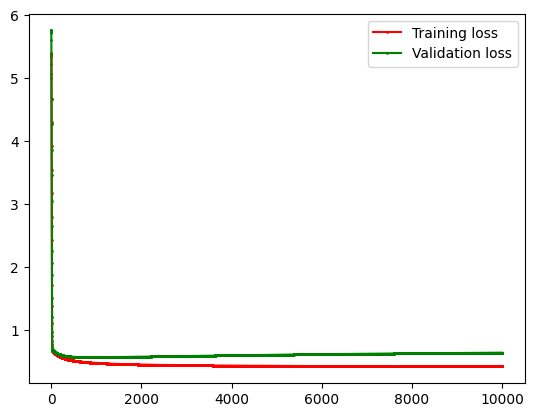

Model parameters (weights): [[-3.16335176]
 [ 1.08853101]
 [ 0.71350466]
 [-0.8911023 ]
 [ 1.66226609]
 [ 0.5786216 ]
 [ 0.3065608 ]
 [-0.22656249]
 [ 0.60023229]
 [ 1.34775177]
 [ 1.12105697]
 [ 0.13582979]
 [ 0.91532985]
 [-0.25514498]
 [-1.06000782]
 [ 0.02580588]
 [ 1.29641721]
 [ 0.46583142]
 [ 0.708017  ]
 [-0.36421518]
 [ 1.03551315]
 [ 0.91255039]
 [-0.28515676]
 [ 0.96740435]
 [-0.2501886 ]
 [ 1.86846412]
 [ 1.65606493]
 [ 1.427259  ]
 [ 1.94460281]
 [ 2.01542746]
 [ 1.41402383]
 [-2.26918045]
 [ 1.53705993]
 [-0.36344481]
 [ 0.19244885]
 [-1.44748147]
 [ 0.70819491]
 [-1.04435298]
 [-2.97198857]
 [-0.42692794]
 [-1.24261354]
 [-0.41796296]
 [-0.98414705]
 [-1.22924233]
 [ 0.50058516]
 [-0.04456719]
 [ 0.02405468]
 [ 0.32226938]
 [-0.64850895]
 [-0.66593166]
 [-0.48056443]
 [ 0.32707679]
 [ 0.17495455]
 [-0.61593367]
 [-0.36535728]
 [ 0.49267489]
 [-0.85987899]
 [-1.26373002]
 [-0.28735217]
 [ 0.57001036]
 [-1.02409882]
 [ 0.71907016]
 [ 0.6272286 ]
 [-1.5667075 ]
 [ 0.1079384

In [61]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='l2', reg_lambda=0.0)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


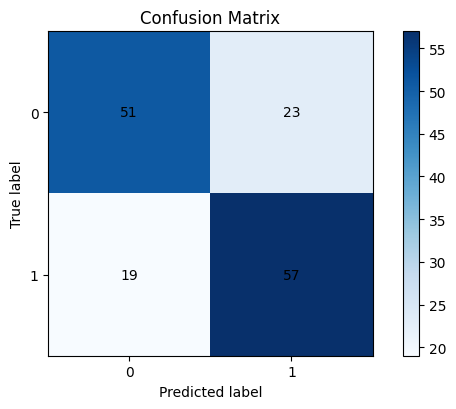

{'Accuracy': 0.72,
 'Precision': 0.7125,
 'Recall': 0.75,
 'F1-score': 0.7307692307692307}

In [62]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)